<a href="https://colab.research.google.com/github/Rut092/End-to-End-AI-Roadmap/blob/main/XGBoost_Lecture_no_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import xgboost as xgb

## Dataset Splitting

In [2]:
X,y = pd.DataFrame(load_wine().data), pd.DataFrame(load_wine().target)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training the Model Using different Params

In [3]:
imbalance_ratio = len(y_train[y_train==0])/len(y_train[y_train==1])
print(imbalance_ratio)

1.0


In [6]:
xg_model = xgb.XGBClassifier(
    n_estimators = 1000,
    learning_rate = 0.05,
    max_depth = 6,
    gamma = 0.5,                       ## Minimum loss required to make a split
    subsample = 0.8,                  ## Use 80% of rows per tree
    colsample_bytree = 0.8,           ## Use 80% of columns per tree
    scale_pos_weight = imbalance_ratio,
    random_state = 42,
    early_stopping_rounds = 20
)

xg_model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose = True                   ## see the error drop tree-by-tree
)

[0]	validation_0-mlogloss:1.02221
[1]	validation_0-mlogloss:0.97128
[2]	validation_0-mlogloss:0.91910
[3]	validation_0-mlogloss:0.87027
[4]	validation_0-mlogloss:0.83099
[5]	validation_0-mlogloss:0.79389
[6]	validation_0-mlogloss:0.75641
[7]	validation_0-mlogloss:0.72042
[8]	validation_0-mlogloss:0.68934
[9]	validation_0-mlogloss:0.65785
[10]	validation_0-mlogloss:0.62818
[11]	validation_0-mlogloss:0.60018
[12]	validation_0-mlogloss:0.57377


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [16:08:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  self.starting_round = model.num_boosted_rounds()


[13]	validation_0-mlogloss:0.55050
[14]	validation_0-mlogloss:0.52889
[15]	validation_0-mlogloss:0.50588
[16]	validation_0-mlogloss:0.48507
[17]	validation_0-mlogloss:0.46494
[18]	validation_0-mlogloss:0.44729
[19]	validation_0-mlogloss:0.43231
[20]	validation_0-mlogloss:0.41523
[21]	validation_0-mlogloss:0.40039
[22]	validation_0-mlogloss:0.38636
[23]	validation_0-mlogloss:0.37239
[24]	validation_0-mlogloss:0.35974
[25]	validation_0-mlogloss:0.34801
[26]	validation_0-mlogloss:0.33469
[27]	validation_0-mlogloss:0.32218
[28]	validation_0-mlogloss:0.31082
[29]	validation_0-mlogloss:0.30132
[30]	validation_0-mlogloss:0.29139
[31]	validation_0-mlogloss:0.28218
[32]	validation_0-mlogloss:0.27346
[33]	validation_0-mlogloss:0.26418
[34]	validation_0-mlogloss:0.25627
[35]	validation_0-mlogloss:0.24856
[36]	validation_0-mlogloss:0.24113
[37]	validation_0-mlogloss:0.23383
[38]	validation_0-mlogloss:0.22553
[39]	validation_0-mlogloss:0.21794
[40]	validation_0-mlogloss:0.21196
[41]	validation_0-ml

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [9]:
importances = xg_model.feature_importances_

In [12]:
feature_names = load_wine().feature_names
for score, name in sorted(zip(importances, feature_names), reverse=True):
    print(name, score)

od280/od315_of_diluted_wines 0.18764156
proline 0.13140556
color_intensity 0.12762345
flavanoids 0.11070702
total_phenols 0.09235857
alcohol 0.08041829
hue 0.060574085
malic_acid 0.044003148
ash 0.03940613
magnesium 0.038530305
alcalinity_of_ash 0.03204354
proanthocyanins 0.031518105
nonflavanoid_phenols 0.023770286


In [13]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Gain)': importances
}).sort_values(by='Importance (Gain)', ascending=False)

In [14]:
print(importance_df)

                         Feature  Importance (Gain)
11  od280/od315_of_diluted_wines           0.187642
12                       proline           0.131406
9                color_intensity           0.127623
6                     flavanoids           0.110707
5                  total_phenols           0.092359
0                        alcohol           0.080418
10                           hue           0.060574
1                     malic_acid           0.044003
2                            ash           0.039406
4                      magnesium           0.038530
3              alcalinity_of_ash           0.032044
8                proanthocyanins           0.031518
7           nonflavanoid_phenols           0.023770


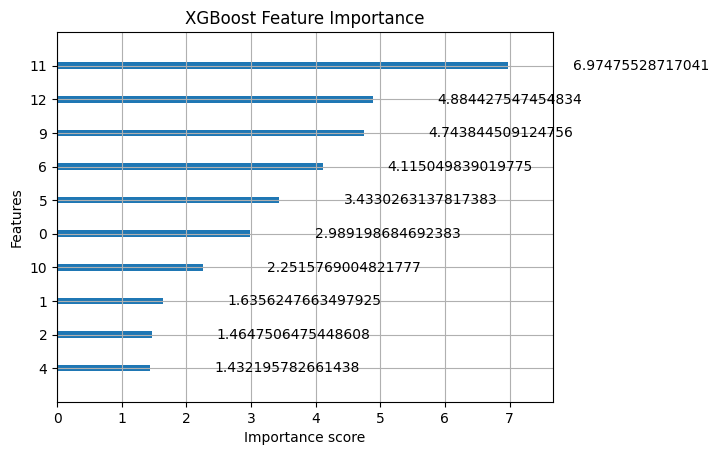

In [20]:
xgb.plot_importance(xg_model, importance_type='gain', max_num_features=10, title="XGBoost Feature Importance")
plt.show()

In [22]:
print(xg_model.get_xgb_params)

<bound method XGBModel.get_xgb_params of XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)>


In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred = xg_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy on Test Set: {accuracy:.4f}")

# Add more detailed classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy on Test Set: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]
